In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rail_df = pd.read_excel("../data/data_old/Patstitchcat_V300icat557ipat1.xlsx")
rail_df = rail_df.iloc[1000:18500]
rail_v350 = pd.read_excel("../data/data_old/Patstitchcat_V350icat557ipat1.xlsx")
rail_v350 = rail_v350.iloc[1000:16000]
rail_df = pd.concat([rail_df,rail_v350])

rail_df = rail_df.rename(index=str, columns={"Force(20Hz)": "Force","Force(raw)":"Raw_Force"})


rail_df = rail_df.dropna()
rail_df.reset_index(drop=True, inplace=True)


rail_df.head()

,Distance [m],Acceleration,Displacement,Force,Raw_Force
0,138.416667,0.785773,0.077908,186.401406,167.853064
1,138.500000,0.095516,0.077847,184.228522,173.328387
2,138.583333,-2.071776,0.077785,182.016232,189.264515
3,138.666667,-2.816802,0.077722,179.783811,195.039796
4,138.750000,-0.776615,0.077656,177.550484,180.959063


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Assume you've already loaded your dataframe as `df`

# Selecting the relevant features
features = rail_df[['Acceleration', 'Displacement']]
target = rail_df['Raw_Force']

# Normalizing the features
scaler = MinMaxScaler(feature_range=(0, 1))
features_scaled = scaler.fit_transform(features)

# Convert the series to sequences for RNN
def create_sequences(features, target, sequence_length):
    X, y = [], []
    for i in range(len(features) - sequence_length):
        X.append(features[i:(i + sequence_length)])
        y.append(target[i + sequence_length])
    return np.array(X), np.array(y)

sequence_length = 10  # Example sequence length
X, y = create_sequences(features_scaled, target, sequence_length)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense,LSTM,Bidirectional,Input,GRU

In [48]:
model = Sequential([
    Bidirectional(SimpleRNN(32, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True)),
    SimpleRNN(32, return_sequences=False),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
X_train.shape[1], X_train.shape[2]

(10, 2)

In [79]:
from keras import regularizers
reg = regularizers.l1_l2(0.01)
def lstm_model(steps=10,feature_size=2, output_size=1,req=True):
    model = Sequential()
    model.add(Input(shape=(steps,feature_size)))
    model.add(Bidirectional(LSTM(16,return_sequences=True,dropout=0.2, recurrent_dropout=0.2,unroll=True,bias_regularizer=reg)))
    model.add(Bidirectional(LSTM(16,return_sequences=False)))
    model.add(Dense(output_size))
    model.compile(loss='mean_squared_error')
    return model
lstm_model = lstm_model()

In [51]:
history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, verbose=1)

Epoch 1/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 28061.8594 - val_loss: 22462.7324
Epoch 2/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 20557.9512 - val_loss: 16654.6348
Epoch 3/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 15097.8242 - val_loss: 12109.0039
Epoch 4/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 10903.8281 - val_loss: 8622.2275
Epoch 5/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 7778.4819 - val_loss: 6044.8379
Epoch 6/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5432.9780 - val_loss: 4244.9731
Epoch 7/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3817.0105 - val_loss: 3091.1399
Epoch 8/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2746.1609 - val_loss: 2443.9189
Epoch 9/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2209.5649 - val_loss: 2149.3799
Epoch 10/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2027.3265 - val_loss: 2051.5659
Epoch 11/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1946.7611 -

In [53]:
y_pred = model.predict(X_test)
y_pred.shape

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


(6498, 1)

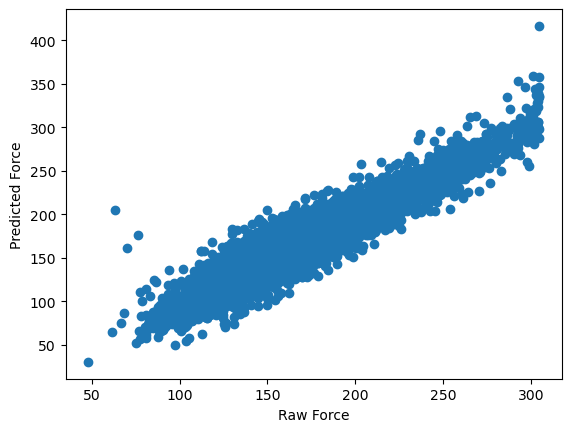

In [54]:
plt.scatter(y_pred,y_test);
plt.xlabel("Raw Force")
plt.ylabel("Predicted Force");

In [80]:
history = lstm_model.fit(X_train, y_train, epochs=50, validation_split=0.1, verbose=1)

Epoch 1/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 28105.5918 - val_loss: 22450.0176
Epoch 2/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 20505.1035 - val_loss: 16159.7363
Epoch 3/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14605.7598 - val_loss: 11032.2764
Epoch 4/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9741.5322 - val_loss: 7063.6431
Epoch 5/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6167.2358 - val_loss: 4254.3394
Epoch 6/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3639.5542 - val_loss: 2598.9756
Epoch 7/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2235.8474 - val_loss: 2048.9697
Epoch 8/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1983.1090 - val_loss: 2025.6713
Epoch 9/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1987.4821 - val_loss: 2025.2286
Epoch 10/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1944.3693 - val_loss: 2025.2578
Epoch 11/50
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1975.8184 - 

In [63]:
lstm_pred = lstm_model.predict(X_test)
lstm_pred.shape

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


(6498, 1)

Text(0, 0.5, 'Predicted Force')

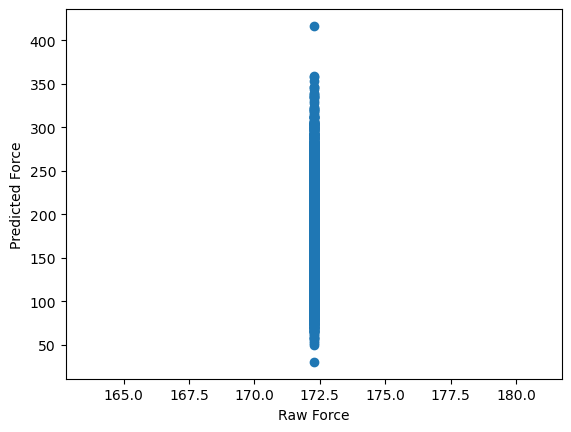

In [69]:
plt.scatter(lstm_pred,y_test);
plt.xlabel("Raw Force")
plt.ylabel("Predicted Force")

In [72]:
def plot_slot(start=500,end=601):
    epoch_count = range(start,end)

    plt.plot(epoch_count, y_test[start:end], 'r--',linewidth=2.0)
    # plt.plot(epoch_count, y_pred[start:end], 'y--',linewidth=2.0)
    plt.plot(epoch_count, y_pred[start:end], 'b--',linewidth=2.0)
    plt.legend(['Raw Force', "RNN pred"])
    plt.xlabel('Time Slots')
    plt.ylabel('Force')
    #plt.title(title)
    plt.show()

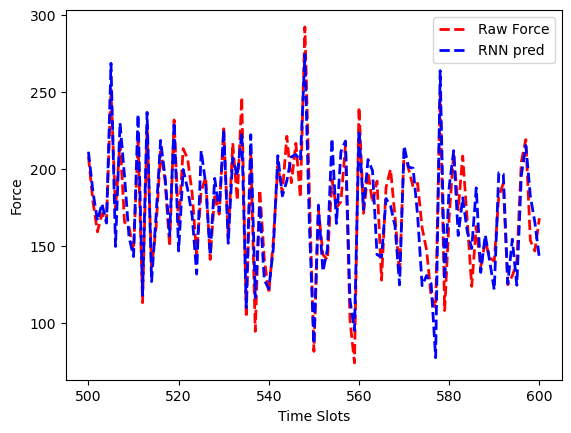

In [73]:
plot_slot()

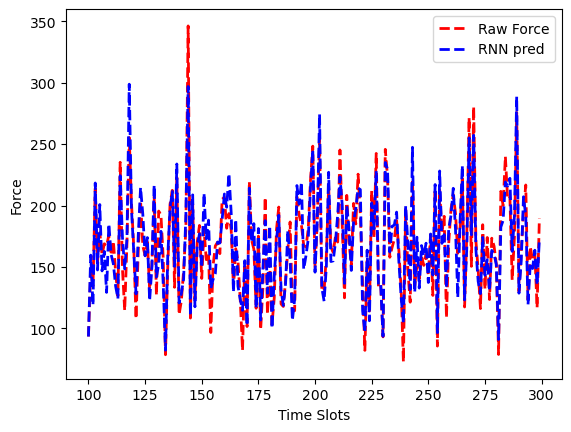

In [76]:
plot_slot(100,300)